# Эмбеддинги с нуля

Ноутбук к теме [`lesson.md`](lesson.md). Строим векторы слов двумя способами — счётным и обучаемым — и проверяем, что это одно и то же.

1. Корпус, совстречаемость, PPMI и SVD
2. Мини-word2vec: SGNS градиентным спуском
3. Проверка Леви–Голдберга: SGNS против сдвинутого PMI
4. Антонимы против синонимов
5. Аналогии и оговорка про исключение входных слов

Корпус синтетический: он порождается шаблонами, поэтому заранее известно, какие слова обязаны оказаться рядом, и утверждения можно проверять.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

C_BG, C_INK, C_GRAY = "#faf9f5", "#141413", "#b0aea5"
C_PANEL, C_ORANGE, C_BLUE, C_GREEN = "#e8e6dc", "#d97757", "#6a9bcc", "#788c5d"
plt.rcParams.update({
    "figure.facecolor": C_BG, "axes.facecolor": C_BG, "axes.edgecolor": C_GRAY,
    "text.color": C_INK, "xtick.color": C_INK, "ytick.color": C_INK,
    "axes.labelcolor": C_INK, "font.size": 11, "legend.frameon": False,
})

def despine(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

## 1. Корпус, совстречаемость, PPMI и SVD

In [2]:
GROUPS = {
    "животное": ["собака", "кошка", "лошадь"],
    "еда": ["хлеб", "сыр", "яблоко"],
    "транспорт": ["машина", "поезд", "лодка"],
}
ANTONYMS = ["горячий", "холодный"]   # намеренно без собственных контекстов

TEMPLATES = {
    "животное": ["во дворе бегает {w}", "я кормлю {w} каждое утро",
                 "{w} спит возле двери", "соседи завели {w} прошлым летом"],
    "еда": ["на столе лежит свежий {w}", "я ем {w} на завтрак",
            "мама купила {w} в магазине", "{w} закончился ещё вчера"],
    "транспорт": ["{w} стоит возле дома", "мы поехали на {w} до города",
                  "{w} сломался посреди дороги", "новый {w} обошёлся дорого"],
    "признак": ["чай сегодня очень {w}", "на улице совсем {w}",
                "суп оказался слишком {w}", "воздух в комнате {w}"],
}
WORD_TEMPLATES = {
    "собака": ["{w} громко лает ночью", "{w} виляет хвостом"],
    "кошка": ["{w} царапает диван", "{w} мурлычет на коленях"],
    "лошадь": ["{w} скачет по полю", "{w} тянет телегу"],
    "хлеб": ["{w} зачерствел за ночь", "{w} режут ножом"],
    "сыр": ["{w} пахнет очень резко", "{w} натирают на тёрке"],
    "яблоко": ["{w} упало с ветки", "{w} червивое внутри"],
    "машина": ["{w} заглохла на светофоре", "{w} требует бензина"],
    "поезд": ["{w} прибыл на платформу", "{w} опоздал на час"],
    "лодка": ["{w} качается на волнах", "{w} течёт по дну"],
}

def build_corpus(seed=0, repeats=60, own_share=0.35):
    rng = np.random.default_rng(seed)
    sents = []
    for group, words in GROUPS.items():
        for _ in range(repeats):
            for w in words:
                own = WORD_TEMPLATES.get(w, [])
                if own and rng.random() < own_share:
                    tpl = own[rng.integers(len(own))]
                else:
                    tpl = TEMPLATES[group][rng.integers(len(TEMPLATES[group]))]
                sents.append(tpl.format(w=w).split())
    for _ in range(repeats):
        for w in ANTONYMS:
            tpl = TEMPLATES["признак"][rng.integers(len(TEMPLATES["признак"]))]
            sents.append(tpl.format(w=w).split())
    rng.shuffle(sents)
    return sents

sents = build_corpus()
print(f"предложений: {len(sents)}")
for s in sents[:5]:
    print("  ", " ".join(s))

предложений: 660
   мама купила сыр в магазине
   яблоко упало с ветки
   мы поехали на машина до города
   соседи завели кошка прошлым летом
   сыр закончился ещё вчера


In [3]:
def cooccurrence(sentences, window=2):
    vocab = sorted({w for s in sentences for w in s})
    index = {w: i for i, w in enumerate(vocab)}
    m = np.zeros((len(vocab), len(vocab)))
    for s in sentences:
        for i, w in enumerate(s):
            lo, hi = max(0, i - window), min(len(s), i + window + 1)
            for j in range(lo, hi):
                if j != i:
                    m[index[w], index[s[j]]] += 1
    return m, vocab, index

def ppmi(counts):
    """log(p(w,c)/(p(w)p(c))) с обнулением отрицательных значений."""
    total = counts.sum()
    p_wc = counts / total
    p_w = p_wc.sum(axis=1, keepdims=True)
    p_c = p_wc.sum(axis=0, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        pmi = np.log(p_wc / (p_w * p_c))
    return np.nan_to_num(np.maximum(pmi, 0.0), nan=0.0, posinf=0.0, neginf=0.0)

def svd_embed(matrix, dim=8):
    u, s, _ = np.linalg.svd(matrix, full_matrices=False)
    return u[:, :dim] * s[:dim]

def cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na and nb else 0.0

counts, vocab, idx = cooccurrence(sents)
emb = svd_embed(ppmi(counts), dim=8)
print(f"словарь: {len(vocab)} слов, эмбеддинги: {emb.shape}")

def neighbours(word, k=4, vectors=None, names=None):
    vectors = emb if vectors is None else vectors
    names = vocab if names is None else names
    i = names.index(word)
    sims = [(cos(vectors[i], vectors[j]), names[j])
            for j in range(len(names)) if j != i]
    return sorted(sims, reverse=True)[:k]

for w in ("собака", "хлеб", "поезд", "горячий"):
    top = ", ".join(f"{n} {s:.2f}" for s, n in neighbours(w))
    print(f"{w:>10}: {top}")

словарь: 100 слов, эмбеддинги: (100, 8)
    собака: двери 0.80, во 0.77, кошка 0.76, лошадь 0.71
      хлеб: вчера 0.93, режут 0.86, ножом 0.86, ночь 0.84
     поезд: машина 1.00, дороги 0.97, волнах 0.95, мы 0.94
   горячий: холодный 1.00, чай 1.00, сегодня 1.00, очень 1.00


Ближайшие соседи собираются по смысловым группам — при том, что никакой разметки мы не давали, только сырой текст.

## 2. Мини-word2vec: SGNS градиентным спуском

Теперь второй подход: не считать статистику, а обучить модель отличать настоящую пару «слово — контекст» от подделок.

In [4]:
def train_sgns(sents, vocab, idx, dim=12, window=2, neg=5,
               epochs=40, lr=0.05, seed=1):
    """Skip-gram с отрицательными примерами, честный SGD."""
    rng = np.random.default_rng(seed)
    v = len(vocab)
    w_in = rng.normal(0, 0.1, (v, dim))
    w_out = rng.normal(0, 0.1, (v, dim))

    pairs = []
    for s in sents:
        for i, word in enumerate(s):
            lo, hi = max(0, i - window), min(len(s), i + window + 1)
            for j in range(lo, hi):
                if j != i:
                    pairs.append((idx[word], idx[s[j]]))
    pairs = np.array(pairs)

    # шумовое распределение в степени 3/4 — эмпирическая находка word2vec
    freq = np.bincount(pairs[:, 1], minlength=v).astype(float)
    noise = freq ** 0.75
    noise /= noise.sum()

    for _ in range(epochs):
        rng.shuffle(pairs)
        for center, context in pairs:
            negatives = rng.choice(v, size=neg, p=noise)
            targets = np.concatenate([[context], negatives])
            labels = np.zeros(neg + 1)
            labels[0] = 1.0
            vec = w_in[center]
            scores = w_out[targets] @ vec
            pred = 1.0 / (1.0 + np.exp(-np.clip(scores, -30, 30)))
            err = pred - labels
            grad_in = err @ w_out[targets]
            w_out[targets] -= lr * np.outer(err, vec)
            w_in[center] -= lr * grad_in
    return w_in, w_out

print(f"пар для обучения: {sum(len(s) * 4 for s in sents):,}".replace(",", " "))
w_in, w_out = train_sgns(sents, vocab, idx)
print("обучено")

for w in ("собака", "хлеб", "поезд"):
    top = ", ".join(f"{n} {s:.2f}" for s, n in neighbours(w, vectors=w_in))
    print(f"{w:>10}: {top}")

пар для обучения: 11 144


обучено
    собака: лошадь 0.82, кошка 0.77, ночью 0.67, двери 0.66
      хлеб: сыр 0.85, яблоко 0.81, ночь 0.61, вчера 0.60
     поезд: лодка 0.79, машина 0.78, час 0.77, платформу 0.74


## 3. Проверка Леви–Голдберга

Утверждение: SGNS неявно раскладывает матрицу сдвинутого PMI, то есть $\vec{w} \cdot \vec{c} \approx \mathrm{PMI}(w,c) - \log k$. Проверим это прямым сопоставлением.

пар с достаточной статистикой: 490
корреляция Пирсона:            r = 0.714


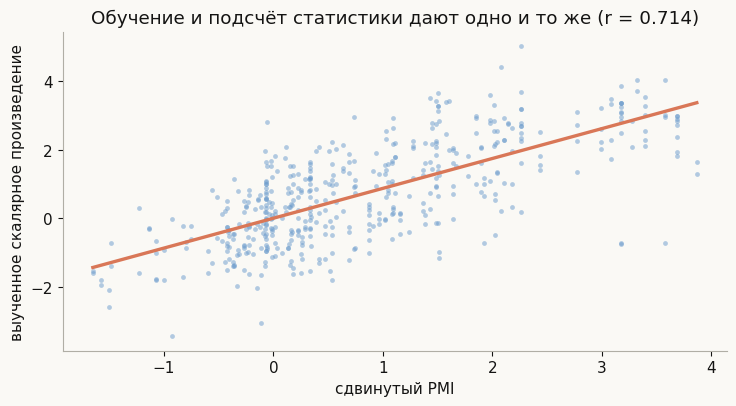

In [5]:
total = counts.sum()
p_wc = counts / total
p_w = p_wc.sum(axis=1, keepdims=True)
p_c = p_wc.sum(axis=0, keepdims=True)
with np.errstate(divide="ignore", invalid="ignore"):
    pmi = np.log(p_wc / (p_w * p_c))
shifted = pmi - np.log(5)          # k = 5 отрицательных примеров

mask = counts > 4                  # только надёжно оценённые пары
dots = (w_in @ w_out.T)[mask]
truth = shifted[mask]
ok = np.isfinite(dots) & np.isfinite(truth)
dots, truth = dots[ok], truth[ok]
r = np.corrcoef(dots, truth)[0, 1]

print(f"пар с достаточной статистикой: {len(dots)}")
print(f"корреляция Пирсона:            r = {r:.3f}")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(truth, dots, s=12, color=C_BLUE, alpha=0.5, linewidths=0)
xs = np.linspace(truth.min(), truth.max(), 50)
ax.plot(xs, np.polyval(np.polyfit(truth, dots, 1), xs), color=C_ORANGE, lw=2.4)
ax.set_xlabel("сдвинутый PMI")
ax.set_ylabel("выученное скалярное произведение")
ax.set_title(f"Обучение и подсчёт статистики дают одно и то же (r = {r:.3f})")
despine(ax)
fig.tight_layout()

Связь линейная и явная. Корреляция не единица — модель крошечная, корпус маленький, — но противопоставление «счётные против обучаемых» методов после такой картинки выглядит совсем иначе.

## 4. Антонимы против синонимов

Главное следствие дистрибутивной гипотезы: близость меряет взаимозаменяемость, а не синонимию.

In [6]:
pairs = [
    ("горячий", "холодный", "антонимы"),
    ("собака", "кошка", "одна группа"),
    ("хлеб", "сыр", "одна группа"),
    ("машина", "поезд", "одна группа"),
    ("собака", "хлеб", "разные группы"),
    ("горячий", "поезд", "разные группы"),
]
print(f"{'пара':>24} {'SVD':>7} {'SGNS':>7}   тип")
for a, b, tag in pairs:
    s_svd = cos(emb[idx[a]], emb[idx[b]])
    s_sg = cos(w_in[idx[a]], w_in[idx[b]])
    print(f"{a + ' ↔ ' + b:>24} {s_svd:>7.3f} {s_sg:>7.3f}   {tag}")

                    пара     SVD    SGNS   тип
      горячий ↔ холодный   1.000   0.994   антонимы
          собака ↔ кошка   0.757   0.774   одна группа
              хлеб ↔ сыр   0.799   0.850   одна группа
          машина ↔ поезд   0.997   0.780   одна группа
           собака ↔ хлеб   0.195  -0.094   разные группы
         горячий ↔ поезд   0.027   0.049   разные группы


Антонимы получают сходство не ниже, чем слова одной тематической группы, и оба метода согласны в этом между собой. В корпусе у «горячий» и «холодный» нет ни одного собственного контекста — они делят все шаблоны, и с точки зрения дистрибутивной гипотезы это буквально одно и то же слово.

## 5. Аналогии и оговорка про исключение входных слов

Знаменитое «король − мужчина + женщина ≈ королева» держится на линейной структуре пространства. Построим корпус, где такая структура есть по построению: взрослые животные и их детёныши в своих наборах контекстов.

In [7]:
ADULT = ["собака", "кошка", "лошадь"]
YOUNG = ["щенок", "котёнок", "жеребёнок"]
SPECIES_TPL = {
    "собака": ["{w} громко лает ночью", "{w} виляет хвостом"],
    "щенок": ["{w} громко лает ночью", "{w} виляет хвостом"],
    "кошка": ["{w} царапает диван", "{w} мурлычет на коленях"],
    "котёнок": ["{w} царапает диван", "{w} мурлычет на коленях"],
    "лошадь": ["{w} скачет по полю", "{w} тянет телегу"],
    "жеребёнок": ["{w} скачет по полю", "{w} тянет телегу"],
}
AGE_TPL = {
    "adult": ["взрослый {w} охраняет дом", "{w} прожил здесь много лет",
              "опытный {w} знает дорогу"],
    "young": ["маленький {w} только родился", "{w} ещё совсем крошечный",
              "неуклюжий {w} учится ходить"],
}

def analogy_corpus(seed=7, repeats=120):
    rng = np.random.default_rng(seed)
    sents = []
    for words, age in ((ADULT, "adult"), (YOUNG, "young")):
        for _ in range(repeats):
            for w in words:
                if rng.random() < 0.5:
                    tpl = SPECIES_TPL[w][rng.integers(len(SPECIES_TPL[w]))]
                else:
                    tpl = AGE_TPL[age][rng.integers(len(AGE_TPL[age]))]
                sents.append(tpl.format(w=w).split())
    rng.shuffle(sents)
    return sents

a_sents = analogy_corpus()
a_counts, a_vocab, a_idx = cooccurrence(a_sents)
a_emb = svd_embed(ppmi(a_counts), dim=6)
print(f"корпус аналогий: {len(a_sents)} предложений, {len(a_vocab)} слов")

корпус аналогий: 720 предложений, 40 слов


In [8]:
def analogy(a, b, c, exclude_inputs=True, k=5):
    """b − a + c: «щенок относится к собаке, как котёнок к ?»"""
    target = a_emb[a_idx[b]] - a_emb[a_idx[a]] + a_emb[a_idx[c]]
    scored = []
    for w in a_vocab:
        if exclude_inputs and w in (a, b, c):
            continue
        scored.append((cos(target, a_emb[a_idx[w]]), w))
    return sorted(scored, reverse=True)[:k]

print("щенок → собака, котёнок → ?\n")
for flag, label in ((True, "входные исключены"), (False, "входные оставлены")):
    top = analogy("щенок", "собака", "котёнок", exclude_inputs=flag)
    line = ", ".join(f"{w} {s:.3f}" for s, w in top)
    print(f"{label:>20}: {line}")

# а где вообще оказались входные слова?
target = a_emb[a_idx["собака"]] - a_emb[a_idx["щенок"]] + a_emb[a_idx["котёнок"]]
ranked = sorted(((cos(target, a_emb[a_idx[w]]), w) for w in a_vocab), reverse=True)
print("\nпозиции входных слов в полном списке:")
for pos, (sc, w) in enumerate(ranked, start=1):
    if w in ("щенок", "собака", "котёнок"):
        print(f"   {w:>10}: место {pos:>2}, сходство {sc:.3f}")

щенок → собака, котёнок → ?

   входные исключены: кошка 0.996, охраняет 0.797, коленях 0.778, знает 0.718, царапает 0.616
   входные оставлены: кошка 0.996, охраняет 0.797, коленях 0.778, знает 0.718, царапает 0.616

позиции входных слов в полном списке:
       собака: место 10, сходство 0.585
      котёнок: место 11, сходство 0.555
        щенок: место 21, сходство 0.126


Аналогия сработала: ближайшим оказалась «кошка» со сходством 0.996, и списки с исключением входных слов и без него **совпали**.

То есть знаменитая оговорка здесь не проявилась: входные слова не попали даже в первую пятёрку. Это честный результат, и он кое-что говорит. Корпус построен так, что линейная структура в нём есть буквально по конструкции: «взрослость» и «вид животного» кодируются независимыми наборами контекстов. Когда структура настолько чистая, арифметика работает без костылей.

На настоящих эмбеддингах, обученных на шумном тексте, ситуация другая — и именно поэтому стандартная методика оценки аналогий исключает входные слова всегда (см. критику: Linzen, 2016). Смысл упражнения не в том, чтобы уличить метод, а в том, чтобы знать: часть убедительности знаменитого примера обеспечена постобработкой, и величина этого вклада зависит от того, насколько чисты данные.